In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [27]:
df = pd.read_csv("diabetic_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print(df.info())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [29]:
print(df.columns.tolist())


['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [31]:
print(df["readmitted"].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [30]:
df["target"] = (df["readmitted"] == "<30").astype(int)

print(df["target"].value_counts())

target
0    90409
1    11357
Name: count, dtype: int64


In [32]:
df = df.drop(
    columns=[
        "encounter_id",
        "patient_nbr",
        "readmitted"
    ]
)

In [33]:
features = [
    "age",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

X = df[features].copy()
y = df["target"]

In [34]:
def convert_age(age):
    age = age.replace("[", "").replace(")", "")
    low, high = age.split("-")
    return (int(low) + int(high)) / 2


X["age"] = X["age"].apply(convert_age)

In [35]:
X = X.replace("?", np.nan)

In [36]:
X = X.fillna(X.median())

In [37]:
print("Missing values:", X.isnull().sum().sum())

Missing values: 0


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    
    random_state=42
)

In [41]:
model.fit(
    X_train_scaled,
    y_train
)

c:\Users\krish\python\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the opti

In [42]:
y_probability = model.predict_proba(
    X_test_scaled
)[:, 1]

In [43]:
auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", auc)

ROC-AUC: 0.6402071878891632


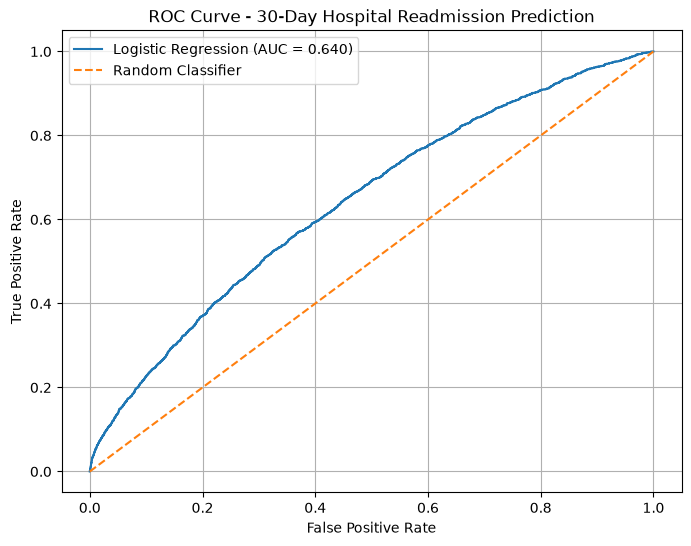

In [44]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - 30-Day Hospital Readmission Prediction"
)

plt.legend()
plt.grid()

plt.show()

In [45]:
threshold = 0.50

y_pred = (
    y_probability >= threshold
).astype(int)

In [46]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[18049    34]
 [ 2239    32]]


In [47]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No 30-Day Readmission",
            "30-Day Readmission"
        ],
        zero_division=0
    )
)


Classification Report:
                       precision    recall  f1-score   support

No 30-Day Readmission       0.89      1.00      0.94     18083
   30-Day Readmission       0.48      0.01      0.03      2271

             accuracy                           0.89     20354
            macro avg       0.69      0.51      0.48     20354
         weighted avg       0.84      0.89      0.84     20354



In [49]:
thresholds_to_test = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50
]

for threshold in thresholds_to_test:

    predictions = (
        y_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.153 | Recall: 0.626 | F1: 0.246
Threshold: 0.20 | Precision: 0.273 | Recall: 0.115 | F1: 0.162
Threshold: 0.30 | Precision: 0.400 | Recall: 0.051 | F1: 0.091
Threshold: 0.40 | Precision: 0.477 | Recall: 0.028 | F1: 0.052
Threshold: 0.50 | Precision: 0.485 | Recall: 0.014 | F1: 0.027


In [50]:
threshold = 0.10

y_pred_final = (
    y_probability >= threshold
).astype(int)

In [51]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10226  7857]
 [  850  1421]]


In [52]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=[
            "No 30-Day Readmission",
            "30-Day Readmission"
        ],
        zero_division=0
    )
)

Classification Report:
                       precision    recall  f1-score   support

No 30-Day Readmission       0.92      0.57      0.70     18083
   30-Day Readmission       0.15      0.63      0.25      2271

             accuracy                           0.57     20354
            macro avg       0.54      0.60      0.47     20354
         weighted avg       0.84      0.57      0.65     20354



In [53]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

              Feature  Coefficient  Odds_Ratio
7    number_inpatient     0.343126    1.409346
8    number_diagnoses     0.081289    1.084684
1    time_in_hospital     0.066652    1.068924
4     num_medications     0.057398    1.059077
0                 age     0.055619    1.057195
6    number_emergency     0.029333    1.029767
2  num_lab_procedures     0.000169    1.000169
5   number_outpatient    -0.003410    0.996596
3      num_procedures    -0.040471    0.960337


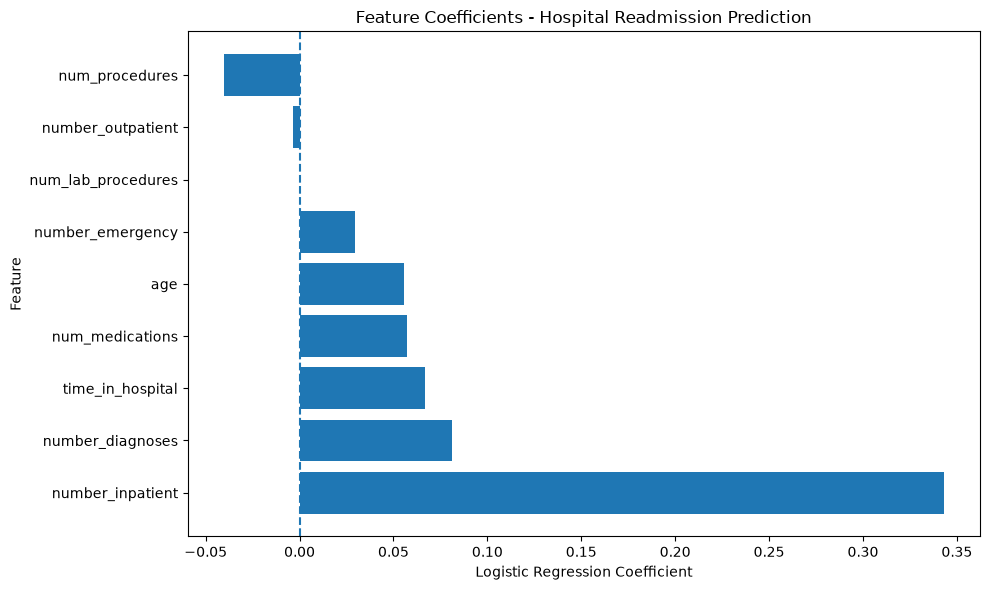

In [54]:
plt.figure(figsize=(10, 6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.title(
    "Feature Coefficients - Hospital Readmission Prediction"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [ ]:
print("========== FINAL RESULTS ==========")

print(f"ROC-AUC: {auc:.3f}")
print("Final Threshold: 0.10")

print("\nConfusion Matrix:")
print(cm)

print("\nTrue Positives:", cm[1, 1])
print("False Positives:", cm[0, 1])
print("True Negatives:", cm[0, 0])
print("False Negatives:", cm[1, 0])

print(
    "\nReadmission Recall:",
    recall_score(y_test, y_pred_final)
)

print(
    "Readmission Precision:",
    precision_score(
        y_test,
        y_pred_final,
        zero_division=0
    )
)

========== FINAL RESULTS ==========
ROC-AUC: 0.640
Final Threshold: 0.10

Confusion Matrix:
[[10226  7857]
 [  850  1421]]

True Positives: 1421
False Positives: 7857
True Negatives: 10226
False Negatives: 850

Readmission Recall: 0.6257155438132981
Readmission Precision: 0.15315800819142056


: 